In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


eth_df = pd.read_csv('../data/ethiopia.csv')

# Adding a country tag so I can identify this data when I combine it later for Task 3
eth_df['Country'] = 'Ethiopia'


eth_df['Date'] = pd.to_datetime(eth_df['YEAR'] * 1000 + eth_df['DOY'], format='%Y%j')

eth_df['Month'] = eth_df['Date'].dt.month

# to 

In [12]:
# --- Cleaning---

# NASA uses -999 for missing values. I'm replacing these with NaN
# If I don't, my averages will be totally wrong.
eth_df.replace(-999, np.nan, inplace=True)

# Checking if any rows were accidentally duplicated during the download
dupes = eth_df.duplicated().sum()
print(f"Found {dupes} duplicate rows. Dropping them...")
eth_df.drop_duplicates(inplace=True)

# to see how much data is actually missing after the -999 fix
print("\nMissing values per column:")
print(eth_df.isna().sum())

# I'll use forward-fill to plug any small gaps.
eth_df.ffill(inplace=True)

Found 0 duplicate rows. Dropping them...

Missing values per column:
YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month          0
dtype: int64


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,11.73,22.75,3.44,19.31,0.00,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.00,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.00,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.00,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.00,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,16.99,24.29,11.80,12.49,5.27,73.87,1.79,3.09,76.60,11.17,Ethiopia,2026-03-27,3
4104,2026,87,15.29,19.58,12.08,7.50,6.46,80.85,1.13,2.35,76.59,11.29,Ethiopia,2026-03-28,3
4105,2026,88,16.28,22.34,11.69,10.65,9.53,77.96,1.30,2.39,76.48,11.42,Ethiopia,2026-03-29,3
4106,2026,89,17.66,25.31,11.08,14.23,0.85,68.88,2.02,3.80,76.44,10.64,Ethiopia,2026-03-30,3


In [13]:
# --- Outliers ---

# I want to check for extreme weather events. 
# Using a Z-score of 3 as the cutoff for confusing data.
cols_to_test = ['T2M', 'PRECTOTCORR', 'RH2M', 'WS2M']
z_scores = np.abs(stats.zscore(eth_df[cols_to_test]))

# Printing count of outliers
print("Number of outlier days found (|Z| > 3):")
print((z_scores > 3).sum())

# Decision: I'm keeping the outliers. For COP32, we need to show extreme 
# heat and flood events, so deleting them would hide the real climate signals.

# Saving this clean version to the data folder for the next task
eth_df.to_csv('../data/ethiopia_clean.csv', index=False)

Number of outlier days found (|Z| > 3):
114


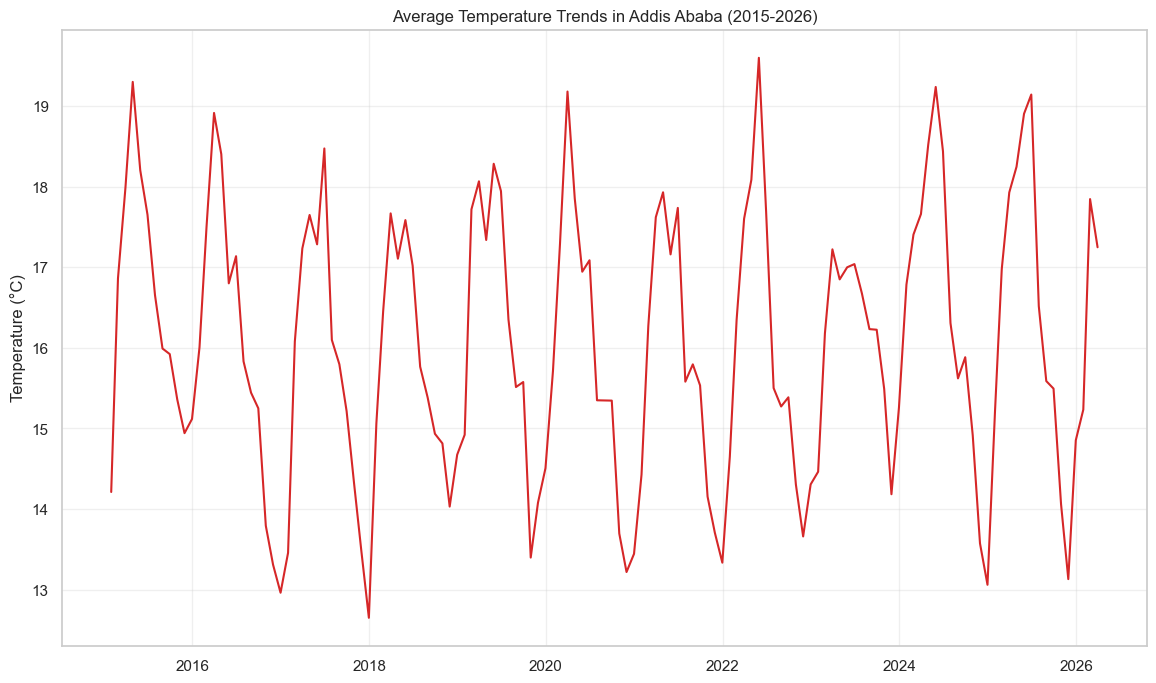

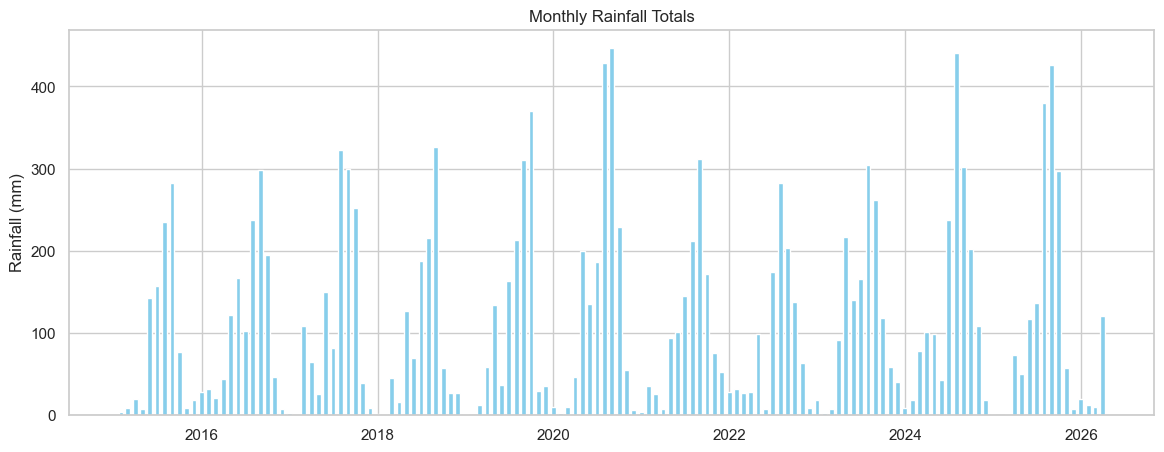

: 

In [ ]:
# --- Visualizing Trends ---

plt.figure(figsize=(14, 8))

# Grouping by month to see the big picture (using 'ME' for the newer pandas version)
monthly_temp = eth_df.resample('ME', on='Date')['T2M'].mean()

plt.plot(monthly_temp.index, monthly_temp.values, color='tab:red', label='Mean Temp')
plt.title('Average Temperature Trends in Addis Ababa (2015-2026)')
plt.ylabel('Temperature (°C)')
plt.grid(True, alpha=0.3)
plt.show()

# Now looking at Rainfall
plt.figure(figsize=(14, 5))
monthly_rain = eth_df.resample('ME', on='Date')['PRECTOTCORR'].sum()
plt.bar(monthly_rain.index, monthly_rain.values, color='skyblue', width=20)
plt.title('Monthly Rainfall Totals')
plt.ylabel('Rainfall (mm)')
plt.show()

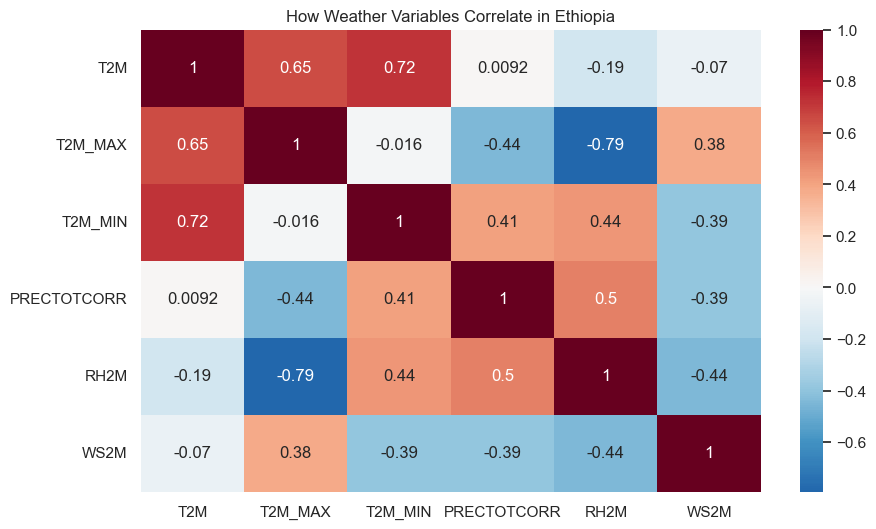

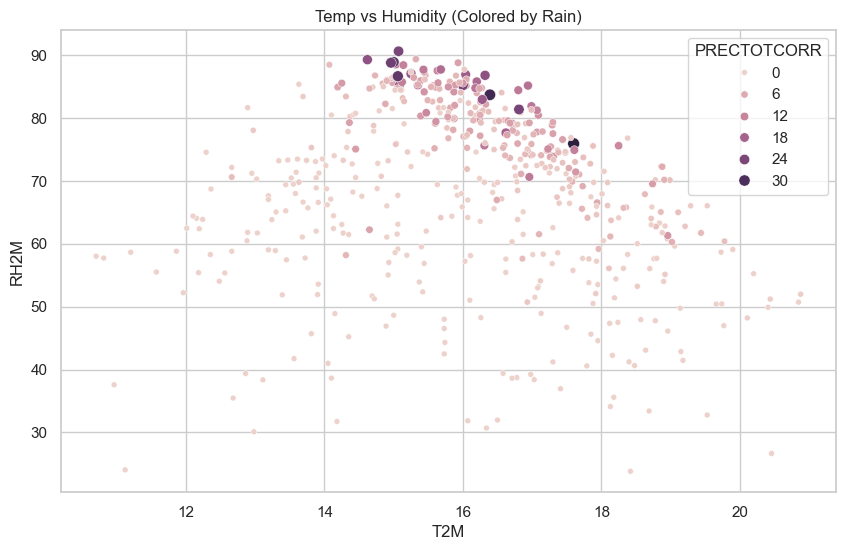

In [ ]:
# --- Correlation Check ---

# I wanted to check if the hotter days are also the windiest or driest.
plt.figure(figsize=(10, 6))
corr_matrix = eth_df[['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M']].corr()

sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0)
plt.title('How Weather Variables Correlate in Ethiopia')
plt.show()

#

In [ ]:
"The data shows that Addis Ababa has a very stable temperature range, but the rainfall peaks are quite extreme, which matches the outlier analysis showing over 90 high-precipitation days."